1) Install & Import Libraries


In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GroupKFold, GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


 2) Load Dataset

In [2]:
df = pd.read_csv('/content/gait.csv')

condition_map = {1: 'Slow', 2: 'Normal', 3: 'Fast'}
joint_map     = {1: 'Hip',  2: 'Knee',  3: 'Ankle'}
leg_map       = {1: 'Left', 2: 'Right'}

df['condition_label'] = df['condition'].map(condition_map)
df['joint_name']      = df['joint'].map(joint_map)
df['leg_name']        = df['leg'].map(leg_map)

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Conditions : {df["condition_label"].unique()}')
print(f'   Joints     : {df["joint_name"].unique()}')
df.head()

✅ Dataset loaded: 181,800 rows × 10 columns
   Conditions : ['Slow' 'Normal' 'Fast']
   Joints     : ['Hip' 'Knee' 'Ankle']


,subject,condition,replication,leg,joint,time,angle,condition_label,joint_name,leg_name
0,1,1,1,1,1,0,4.682881,Slow,Hip,Left
1,1,1,1,1,1,1,5.073127,Slow,Hip,Left
2,1,1,1,1,1,2,5.229774,Slow,Hip,Left
3,1,1,1,1,1,3,5.083273,Slow,Hip,Left
4,1,1,1,1,1,4,4.652399,Slow,Hip,Left


3) Feature Engineering

In [3]:
print('🔧 Engineering features per gait trial...')

pivot = (df
         .pivot_table(index=['subject', 'condition', 'replication', 'leg', 'time'],
                      columns='joint_name',
                      values='angle')
         .reset_index())
pivot.columns.name = None

def extract_features(group):
    feats = {}
    for joint in ['Hip', 'Knee', 'Ankle']:
        if joint not in group.columns:
            continue
        s = group[joint]
        feats[f'{joint}_mean']     = s.mean()
        feats[f'{joint}_std']      = s.std()
        feats[f'{joint}_min']      = s.min()
        feats[f'{joint}_max']      = s.max()
        feats[f'{joint}_range']    = s.max() - s.min()
        feats[f'{joint}_median']   = s.median()
        feats[f'{joint}_velocity'] = s.diff().abs().mean()
        feats[f'{joint}_skewness']    = s.skew()
        feats[f'{joint}_kurtosis']    = s.kurtosis()
        feats[f'{joint}_iqr']         = s.quantile(0.75) - s.quantile(0.25)
        feats[f'{joint}_zero_cross']  = ((s[:-1].values * s[1:].values) < 0).sum()
    return pd.Series(feats)

features_df = (pivot
               .groupby(['subject', 'condition', 'replication', 'leg'])
               .apply(extract_features)
               .reset_index())

print(f'   → {len(features_df)} trial-level feature rows')
print(f'   → {features_df.shape[1] - 4} features per trial')
features_df.head()

🔧 Engineering features per gait trial...
   → 600 trial-level feature rows
   → 33 features per trial


,subject,condition,replication,leg,Hip_mean,Hip_std,Hip_min,Hip_max,Hip_range,Hip_median,...,Ankle_std,Ankle_min,Ankle_max,Ankle_range,Ankle_median,Ankle_velocity,Ankle_skewness,Ankle_kurtosis,Ankle_iqr,Ankle_zero_cross
0,1,1,1,1,7.850984,5.137240,-7.352817,13.369976,20.722793,9.324105,...,12.563371,-15.965032,21.401424,37.366456,5.766747,0.778677,-0.238192,-1.425915,23.779447,2.0
1,1,1,1,2,7.061943,4.313286,-2.373065,13.584862,15.957927,7.514537,...,12.731324,-13.538889,22.082553,35.621442,6.789628,0.735353,-0.177083,-1.558366,25.940221,2.0
2,1,1,2,1,7.003371,5.667427,-10.021197,13.221472,23.242669,8.504841,...,12.990357,-17.492003,20.484142,37.976146,3.547414,0.771904,-0.161309,-1.497342,25.688361,2.0
3,1,1,2,2,7.019926,4.114043,-3.122549,11.865704,14.988253,7.620489,...,12.736948,-13.201554,24.109056,37.310610,8.546590,0.767214,-0.198873,-1.494545,24.667323,2.0
4,1,1,3,1,6.907690,5.103548,-7.873404,12.662596,20.536000,7.925161,...,12.743381,-16.231325,21.261535,37.492859,4.727032,0.788130,-0.170421,-1.484273,24.185602,2.0


4)  Prepare Data & Train/Test Split

In [4]:
# Group by subject so same person never appears in both train and test
groups = features_df['subject'].values

n_subjects = features_df['subject'].nunique()
print(f'✅ Number of unique subjects: {n_subjects}')

feature_cols = [c for c in features_df.columns
                if c not in ['subject', 'condition', 'replication', 'leg']]

X = features_df[feature_cols].values
y = features_df['condition'].values
label_names = ['Slow', 'Normal', 'Fast']

# Split by SUBJECT, not by random row, so no person appears in both train and test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

gkf = GroupKFold(n_splits=5)

print(f'✅ Train samples : {len(X_train_raw)}')
print(f'   Test  samples : {len(X_test_raw)}')
print(f'   Features      : {len(feature_cols)}')
print(f'   Train subjects: {len(set(groups_train))}, Test subjects: {len(set(groups[test_idx]))}')

✅ Number of unique subjects: 10
✅ Train samples : 480
   Test  samples : 120
   Features      : 33
   Train subjects: 8, Test subjects: 2


5.1. Train Decision Tree

🌳 Training Decision Tree classifier...
   Subject-wise CV Accuracy : 67.0% ± 11.0%
   Test Set Accuracy        : 59.2%

📋 Classification Report:
              precision    recall  f1-score   support

        Slow       0.68      0.57      0.62        40
      Normal       0.82      0.57      0.68        40
        Fast       0.43      0.62      0.51        40

    accuracy                           0.59       120
   macro avg       0.64      0.59      0.60       120
weighted avg       0.64      0.59      0.60       120



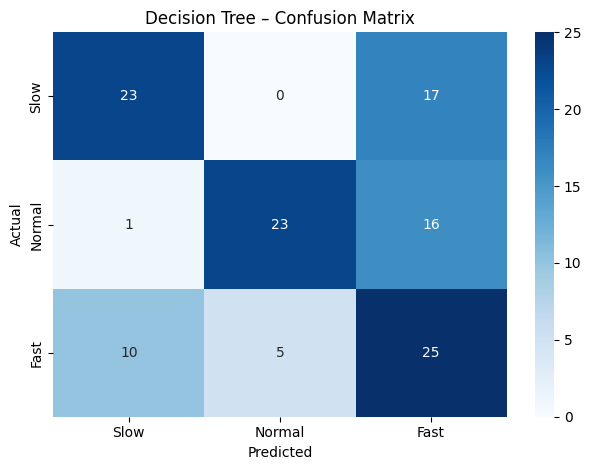

In [5]:
print('🌳 Training Decision Tree classifier...')

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_raw, y_train)

cv_scores_dt = cross_val_score(dt, X, y, cv=gkf, groups=groups, scoring='accuracy')
print(f'   Subject-wise CV Accuracy : {cv_scores_dt.mean()*100:.1f}% ± {cv_scores_dt.std()*100:.1f}%')

y_pred_dt = dt.predict(X_test_raw)
test_acc_dt = accuracy_score(y_test, y_pred_dt)
print(f'   Test Set Accuracy        : {test_acc_dt*100:.1f}%')

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_dt, target_names=label_names))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Decision Tree – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('regenexo_dt_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

5.2. Train Random Forest


🌲 Training Random Forest classifier...
   Subject-wise CV Accuracy : 75.5% ± 7.8%
   Test Set Accuracy        : 80.8%

📋 Classification Report:
              precision    recall  f1-score   support

        Slow       0.69      1.00      0.82        40
      Normal       0.92      0.88      0.90        40
        Fast       0.92      0.55      0.69        40

    accuracy                           0.81       120
   macro avg       0.84      0.81      0.80       120
weighted avg       0.84      0.81      0.80       120



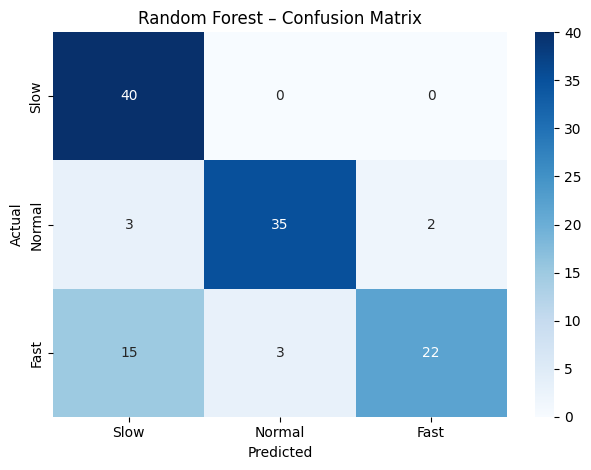

In [6]:
print('🌲 Training Random Forest classifier...')

rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_split=2,
    random_state=42, n_jobs=-1
)
rf.fit(X_train_raw, y_train)

cv_scores_rf = cross_val_score(rf, X, y, cv=gkf, groups=groups, scoring='accuracy')
print(f'   Subject-wise CV Accuracy : {cv_scores_rf.mean()*100:.1f}% ± {cv_scores_rf.std()*100:.1f}%')

y_pred_rf = rf.predict(X_test_raw)
test_acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'   Test Set Accuracy        : {test_acc_rf*100:.1f}%')

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=label_names))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Random Forest – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('regenexo_rf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

5.3. Train Extra Trees

🌴 Training Extra Trees classifier...
   Subject-wise CV Accuracy : 77.2% ± 8.4%
   Test Set Accuracy        : 80.8%

📋 Classification Report:
              precision    recall  f1-score   support

        Slow       0.69      1.00      0.82        40
      Normal       0.94      0.85      0.89        40
        Fast       0.88      0.57      0.70        40

    accuracy                           0.81       120
   macro avg       0.84      0.81      0.80       120
weighted avg       0.84      0.81      0.80       120



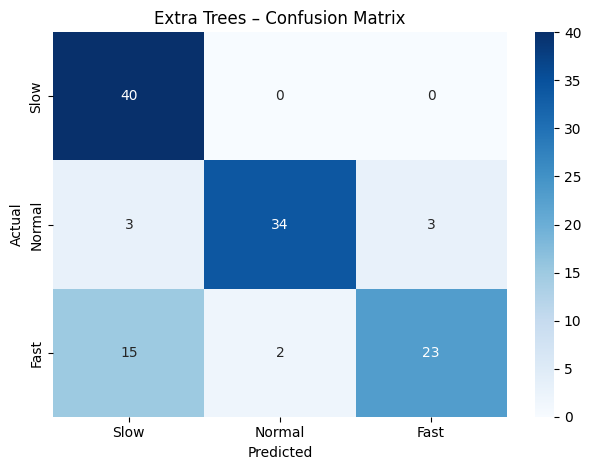

In [7]:
print('🌴 Training Extra Trees classifier...')

et = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)
et.fit(X_train_raw, y_train)

cv_scores_et = cross_val_score(et, X, y, cv=gkf, groups=groups, scoring='accuracy')
print(f'   Subject-wise CV Accuracy : {cv_scores_et.mean()*100:.1f}% ± {cv_scores_et.std()*100:.1f}%')

y_pred_et = et.predict(X_test_raw)
test_acc_et = accuracy_score(y_test, y_pred_et)
print(f'   Test Set Accuracy        : {test_acc_et*100:.1f}%')

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_et, target_names=label_names))

cm_et = confusion_matrix(y_test, y_pred_et)
sns.heatmap(cm_et, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Extra Trees – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('regenexo_et_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

5.4. Train Gradient Boosting

🚀 Training Gradient Boosting classifier...
   Subject-wise CV Accuracy : 77.5% ± 8.4%
   Test Set Accuracy        : 82.5%

📋 Classification Report:
              precision    recall  f1-score   support

        Slow       0.77      1.00      0.87        40
      Normal       0.89      0.85      0.87        40
        Fast       0.83      0.62      0.71        40

    accuracy                           0.82       120
   macro avg       0.83      0.83      0.82       120
weighted avg       0.83      0.82      0.82       120



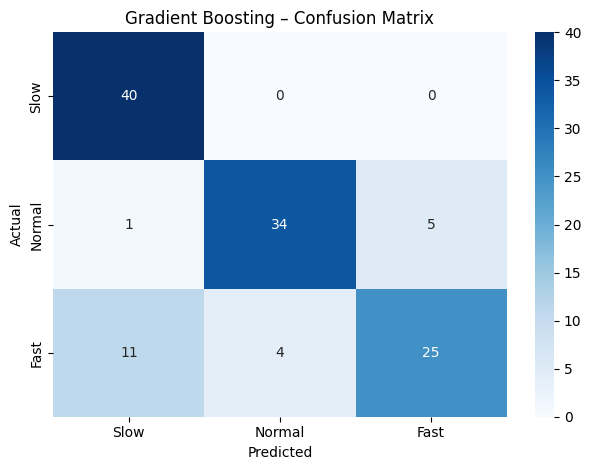

In [8]:
print('🚀 Training Gradient Boosting classifier...')

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_raw, y_train)

cv_scores_gb = cross_val_score(gb, X, y, cv=gkf, groups=groups, scoring='accuracy')
print(f'   Subject-wise CV Accuracy : {cv_scores_gb.mean()*100:.1f}% ± {cv_scores_gb.std()*100:.1f}%')

y_pred_gb = gb.predict(X_test_raw)
test_acc_gb = accuracy_score(y_test, y_pred_gb)
print(f'   Test Set Accuracy        : {test_acc_gb*100:.1f}%')

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_gb, target_names=label_names))

cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Gradient Boosting – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('regenexo_gb_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

5.5. Train XGBoost

⚡ Training XGBoost classifier...
   Subject-wise CV Accuracy : 76.3% ± 6.6%
   Test Set Accuracy        : 83.3%

📋 Classification Report:
              precision    recall  f1-score   support

        Slow       0.78      1.00      0.88        40
      Normal       0.86      0.90      0.88        40
        Fast       0.89      0.60      0.72        40

    accuracy                           0.83       120
   macro avg       0.84      0.83      0.82       120
weighted avg       0.84      0.83      0.82       120



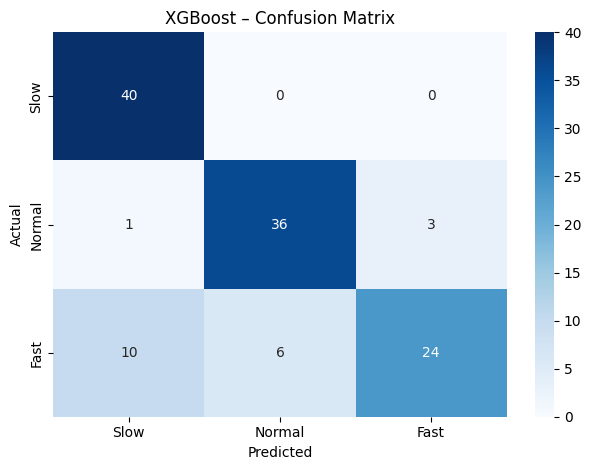

In [9]:
!pip install xgboost --quiet
print('⚡ Training XGBoost classifier...')

from xgboost import XGBClassifier

# XGBoost needs labels starting from 0, but y is 1,2,3 — remap
y_train_xgb = y_train - 1
y_xgb       = y - 1

xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train_raw, y_train_xgb)

cv_scores_xgb = cross_val_score(xgb, X, y_xgb, cv=gkf, groups=groups, scoring='accuracy')
print(f'   Subject-wise CV Accuracy : {cv_scores_xgb.mean()*100:.1f}% ± {cv_scores_xgb.std()*100:.1f}%')

y_pred_xgb = xgb.predict(X_test_raw) + 1   # shift back to 1,2,3
test_acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'   Test Set Accuracy        : {test_acc_xgb*100:.1f}%')

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=label_names))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('XGBoost – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('regenexo_xgb_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

5.6. Train SVM

📐 Training SVM classifier...
   Subject-wise CV Accuracy : 72.2% ± 3.4%
   Test Set Accuracy        : 82.5%

📋 Classification Report:
              precision    recall  f1-score   support

        Slow       0.74      1.00      0.85        40
      Normal       0.95      0.88      0.91        40
        Fast       0.83      0.60      0.70        40

    accuracy                           0.82       120
   macro avg       0.84      0.83      0.82       120
weighted avg       0.84      0.82      0.82       120



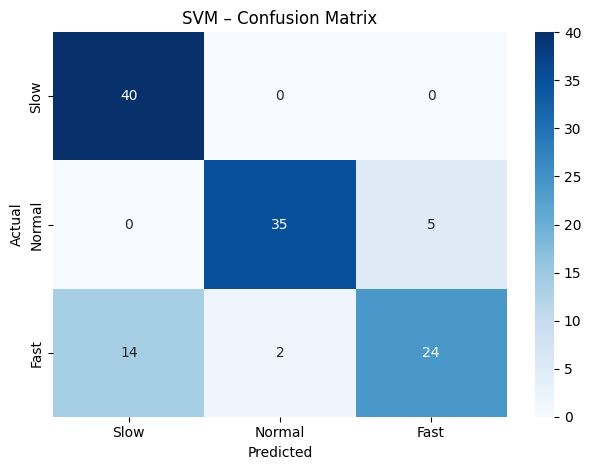

In [10]:
print('📐 Training SVM classifier...')

svm = Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', random_state=42))])
svm.fit(X_train_raw, y_train)

cv_scores_svm = cross_val_score(svm, X, y, cv=gkf, groups=groups, scoring='accuracy')
print(f'   Subject-wise CV Accuracy : {cv_scores_svm.mean()*100:.1f}% ± {cv_scores_svm.std()*100:.1f}%')

y_pred_svm = svm.predict(X_test_raw)
test_acc_svm = accuracy_score(y_test, y_pred_svm)
print(f'   Test Set Accuracy        : {test_acc_svm*100:.1f}%')

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_svm, target_names=label_names))

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('SVM – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('regenexo_svm_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

5.7. Train KNN

📍 Training KNN classifier...
   Subject-wise CV Accuracy : 73.7% ± 8.9%
   Test Set Accuracy        : 85.0%

📋 Classification Report:
              precision    recall  f1-score   support

        Slow       0.74      1.00      0.85        40
      Normal       0.97      0.88      0.92        40
        Fast       0.90      0.68      0.77        40

    accuracy                           0.85       120
   macro avg       0.87      0.85      0.85       120
weighted avg       0.87      0.85      0.85       120



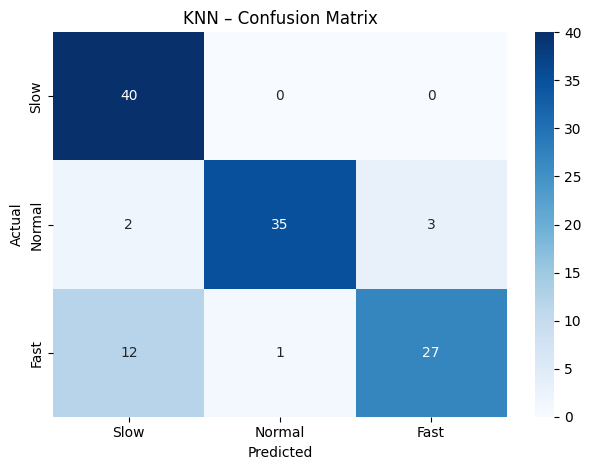

In [11]:
print('📍 Training KNN classifier...')

knn = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=5))])
knn.fit(X_train_raw, y_train)

cv_scores_knn = cross_val_score(knn, X, y, cv=gkf, groups=groups, scoring='accuracy')
print(f'   Subject-wise CV Accuracy : {cv_scores_knn.mean()*100:.1f}% ± {cv_scores_knn.std()*100:.1f}%')

y_pred_knn = knn.predict(X_test_raw)
test_acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'   Test Set Accuracy        : {test_acc_knn*100:.1f}%')

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_knn, target_names=label_names))

cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('KNN – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('regenexo_knn_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

5.8. Train Logistic Regression

📈 Training Logistic Regression classifier...
   Subject-wise CV Accuracy : 73.5% ± 5.1%
   Test Set Accuracy        : 79.2%

📋 Classification Report:
              precision    recall  f1-score   support

        Slow       0.77      1.00      0.87        40
      Normal       1.00      0.68      0.81        40
        Fast       0.68      0.70      0.69        40

    accuracy                           0.79       120
   macro avg       0.82      0.79      0.79       120
weighted avg       0.82      0.79      0.79       120



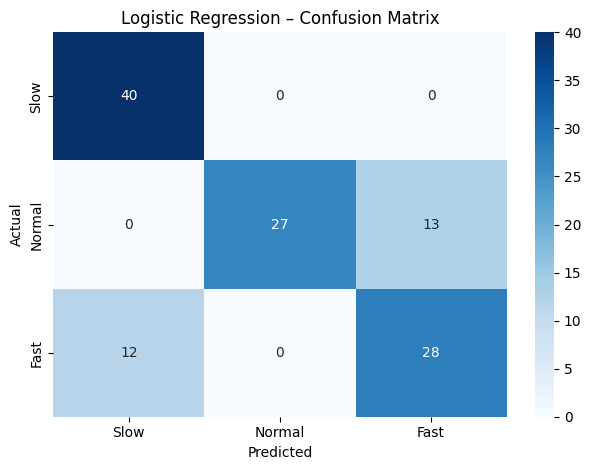

In [12]:
print('📈 Training Logistic Regression classifier...')

logreg = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=42))])
logreg.fit(X_train_raw, y_train)

cv_scores_logreg = cross_val_score(logreg, X, y, cv=gkf, groups=groups, scoring='accuracy')
print(f'   Subject-wise CV Accuracy : {cv_scores_logreg.mean()*100:.1f}% ± {cv_scores_logreg.std()*100:.1f}%')

y_pred_logreg = logreg.predict(X_test_raw)
test_acc_logreg = accuracy_score(y_test, y_pred_logreg)
print(f'   Test Set Accuracy        : {test_acc_logreg*100:.1f}%')

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_logreg, target_names=label_names))

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Logistic Regression – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('regenexo_logreg_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

5.9. Train Naive Bayes

🎲 Training Naive Bayes classifier...
   Subject-wise CV Accuracy : 64.0% ± 3.8%
   Test Set Accuracy        : 66.7%

📋 Classification Report:
              precision    recall  f1-score   support

        Slow       0.51      1.00      0.67        40
      Normal       0.95      0.50      0.66        40
        Fast       1.00      0.50      0.67        40

    accuracy                           0.67       120
   macro avg       0.82      0.67      0.66       120
weighted avg       0.82      0.67      0.66       120



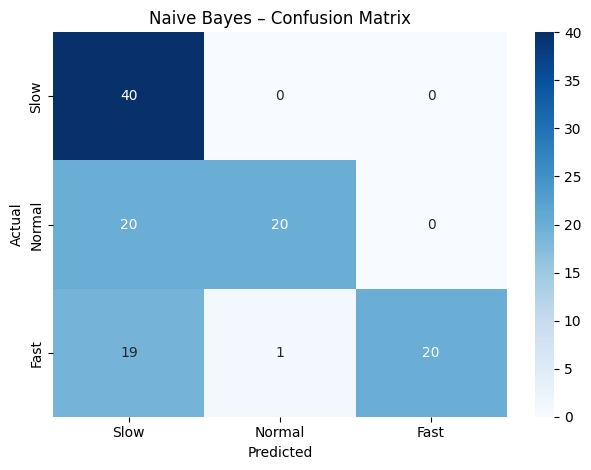

In [13]:
print('🎲 Training Naive Bayes classifier...')

nb = GaussianNB()
nb.fit(X_train_raw, y_train)

cv_scores_nb = cross_val_score(nb, X, y, cv=gkf, groups=groups, scoring='accuracy')
print(f'   Subject-wise CV Accuracy : {cv_scores_nb.mean()*100:.1f}% ± {cv_scores_nb.std()*100:.1f}%')

y_pred_nb = nb.predict(X_test_raw)
test_acc_nb = accuracy_score(y_test, y_pred_nb)
print(f'   Test Set Accuracy        : {test_acc_nb*100:.1f}%')

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_nb, target_names=label_names))

cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Naive Bayes – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('regenexo_nb_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

5.10. Train MLP (Neural Network)

🧠 Training MLP (Neural Network) classifier...
   Subject-wise CV Accuracy : 72.7% ± 5.0%
   Test Set Accuracy        : 80.0%

📋 Classification Report:
              precision    recall  f1-score   support

        Slow       0.71      1.00      0.83        40
      Normal       0.92      0.88      0.90        40
        Fast       0.81      0.53      0.64        40

    accuracy                           0.80       120
   macro avg       0.81      0.80      0.79       120
weighted avg       0.81      0.80      0.79       120



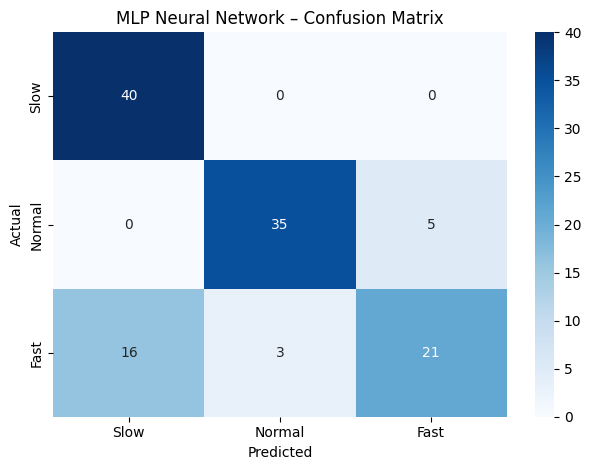

In [14]:
print('🧠 Training MLP (Neural Network) classifier...')

mlp = Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1000, random_state=42))])
mlp.fit(X_train_raw, y_train)

cv_scores_mlp = cross_val_score(mlp, X, y, cv=gkf, groups=groups, scoring='accuracy')
print(f'   Subject-wise CV Accuracy : {cv_scores_mlp.mean()*100:.1f}% ± {cv_scores_mlp.std()*100:.1f}%')

y_pred_mlp = mlp.predict(X_test_raw)
test_acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f'   Test Set Accuracy        : {test_acc_mlp*100:.1f}%')

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_mlp, target_names=label_names))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('MLP Neural Network – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('regenexo_mlp_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
import time

print('⏱️  Measuring training and inference time for all models...\n')

timing_models = {
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1),   # 👈 n_jobs=1
    "Extra Trees":         ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=1),      # 👈 n_jobs=1
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss'),
    "SVM":                 Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', random_state=42))]),
    "KNN":                 Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=5))]),
    "Logistic Regression": Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=42))]),
    "MLP":                 Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1000, random_state=42))]),
    "Naive Bayes":         GaussianNB(),
}

timing_results = []

for name, model in timing_models.items():
    y_tr = y_train_xgb if name == "XGBoost" else y_train

    # Training time
    t0 = time.time()
    model.fit(X_train_raw, y_tr)
    train_time = time.time() - t0

    # Inference time — average per single sample, run 100 times for a stable reading
    single_sample = X_test_raw[0:1]
    t0 = time.time()
    for _ in range(100):
        model.predict(single_sample)
    inference_time_ms = (time.time() - t0) / 100 * 1000   # ms per single prediction

    timing_results.append({
        "Model": name,
        "Train Time (s)": round(train_time, 4),
        "Inference Time (ms/sample)": round(inference_time_ms, 4)
    })
    print(f'   {name:<20} | Train: {train_time:.4f}s | Inference: {inference_time_ms:.4f} ms/sample')

timing_df = pd.DataFrame(timing_results).sort_values("Inference Time (ms/sample)")
print('\n📊 Sorted by inference speed (fastest first):')
print(timing_df.to_string(index=False))

⏱️  Measuring training and inference time for all models...

   Decision Tree        | Train: 0.0343s | Inference: 0.5033 ms/sample
   Random Forest        | Train: 0.8276s | Inference: 10.7324 ms/sample
   Extra Trees          | Train: 0.3394s | Inference: 12.5626 ms/sample
   Gradient Boosting    | Train: 3.0230s | Inference: 2.2525 ms/sample
   XGBoost              | Train: 2.2406s | Inference: 8.7419 ms/sample
   SVM                  | Train: 0.0155s | Inference: 0.6549 ms/sample
   KNN                  | Train: 0.0019s | Inference: 1.3071 ms/sample
   Logistic Regression  | Train: 0.1290s | Inference: 0.4673 ms/sample
   MLP                  | Train: 1.0255s | Inference: 0.9314 ms/sample
   Naive Bayes          | Train: 0.0041s | Inference: 0.2861 ms/sample

📊 Sorted by inference speed (fastest first):
              Model  Train Time (s)  Inference Time (ms/sample)
        Naive Bayes          0.0041                      0.2861
Logistic Regression          0.1290                  

Comparision to find best model

📊 FINAL MODEL COMPARISON — REGENEXO Gait Speed Classification

              Model  Test Accuracy (%)  Subject-wise CV Mean (%)  Subject-wise CV Std (%)
  Gradient Boosting               82.5                      77.5                      8.4
        Extra Trees               80.8                      77.2                      8.4
            XGBoost               83.3                      76.3                      6.6
      Random Forest               80.8                      75.5                      7.8
                KNN               85.0                      73.7                      8.9
Logistic Regression               79.2                      73.5                      5.1
                MLP               80.0                      72.7                      5.0
                SVM               82.5                      72.2                      3.4
      Decision Tree               59.2                      67.0                     11.0
        Naive Bayes               66.

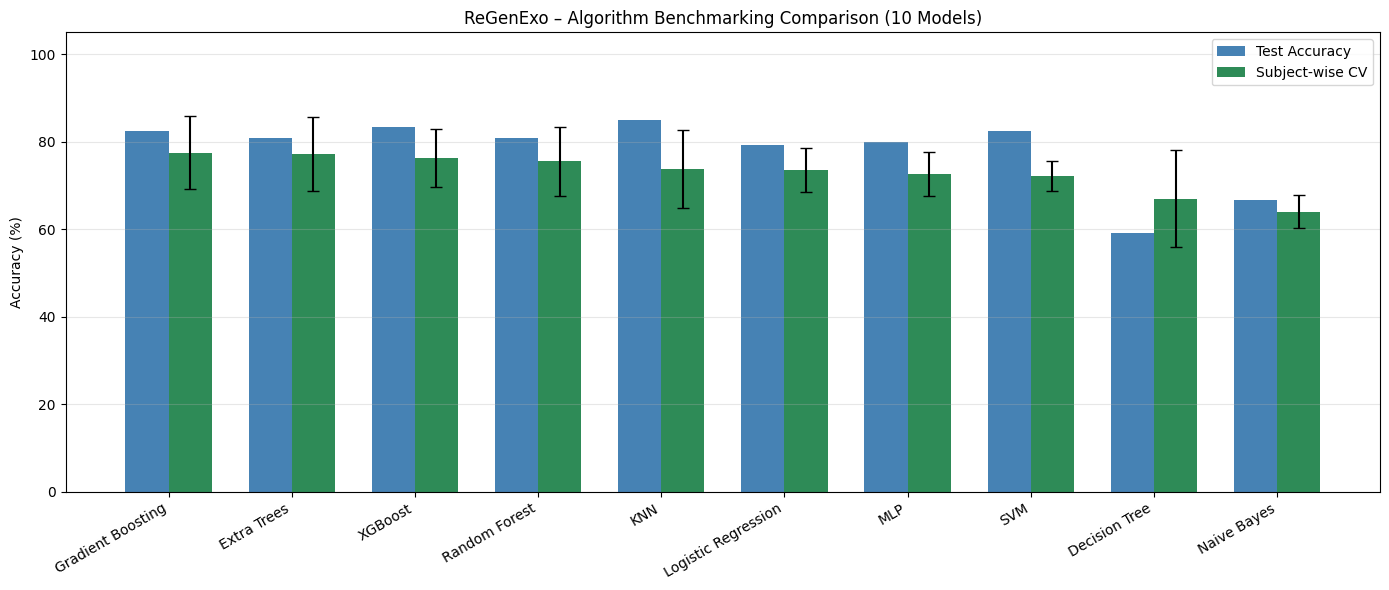


🏆 Best model (by subject-wise CV): Gradient Boosting (77.5% ± 8.4%)


In [16]:
print('📊 FINAL MODEL COMPARISON — REGENEXO Gait Speed Classification\n')

comparison_data = {
    "Model": [
        "Decision Tree", "Random Forest", "Extra Trees", "Gradient Boosting",
        "XGBoost", "SVM", "KNN", "Logistic Regression", "MLP", "Naive Bayes"
    ],
    "Test Accuracy (%)": [
        round(test_acc_dt*100,1), round(test_acc_rf*100,1), round(test_acc_et*100,1),
        round(test_acc_gb*100,1), round(test_acc_xgb*100,1), round(test_acc_svm*100,1),
        round(test_acc_knn*100,1), round(test_acc_logreg*100,1), round(test_acc_mlp*100,1),
        round(test_acc_nb*100,1)
    ],
    "Subject-wise CV Mean (%)": [
        round(cv_scores_dt.mean()*100,1), round(cv_scores_rf.mean()*100,1), round(cv_scores_et.mean()*100,1),
        round(cv_scores_gb.mean()*100,1), round(cv_scores_xgb.mean()*100,1), round(cv_scores_svm.mean()*100,1),
        round(cv_scores_knn.mean()*100,1), round(cv_scores_logreg.mean()*100,1), round(cv_scores_mlp.mean()*100,1),
        round(cv_scores_nb.mean()*100,1)
    ],
    "Subject-wise CV Std (%)": [
        round(cv_scores_dt.std()*100,1), round(cv_scores_rf.std()*100,1), round(cv_scores_et.std()*100,1),
        round(cv_scores_gb.std()*100,1), round(cv_scores_xgb.std()*100,1), round(cv_scores_svm.std()*100,1),
        round(cv_scores_knn.std()*100,1), round(cv_scores_logreg.std()*100,1), round(cv_scores_mlp.std()*100,1),
        round(cv_scores_nb.std()*100,1)
    ],
}

comparison_df = pd.DataFrame(comparison_data).sort_values("Subject-wise CV Mean (%)", ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df["Test Accuracy (%)"], width, label='Test Accuracy', color='steelblue')
ax.bar(x + width/2, comparison_df["Subject-wise CV Mean (%)"], width, label='Subject-wise CV', color='seagreen',
       yerr=comparison_df["Subject-wise CV Std (%)"], capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df["Model"], rotation=30, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('ReGenExo – Algorithm Benchmarking Comparison (10 Models)')
ax.legend()
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('regenexo_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_row = comparison_df.iloc[0]
print(f'\n🏆 Best model (by subject-wise CV): {best_row["Model"]} '
      f'({best_row["Subject-wise CV Mean (%)"]:.1f}% ± {best_row["Subject-wise CV Std (%)"]:.1f}%)')

Dynamically Select Winning Model

In [17]:
model_registry = {
    "Decision Tree":       {"model": dt,     "y_pred": y_pred_dt,     "test_acc": test_acc_dt,     "cv_scores": cv_scores_dt},
    "Random Forest":       {"model": rf,     "y_pred": y_pred_rf,     "test_acc": test_acc_rf,     "cv_scores": cv_scores_rf},
    "Extra Trees":         {"model": et,     "y_pred": y_pred_et,     "test_acc": test_acc_et,     "cv_scores": cv_scores_et},
    "Gradient Boosting":   {"model": gb,     "y_pred": y_pred_gb,     "test_acc": test_acc_gb,     "cv_scores": cv_scores_gb},
    "XGBoost":             {"model": xgb,    "y_pred": y_pred_xgb,    "test_acc": test_acc_xgb,    "cv_scores": cv_scores_xgb},
    "SVM":                 {"model": svm,    "y_pred": y_pred_svm,    "test_acc": test_acc_svm,    "cv_scores": cv_scores_svm},
    "KNN":                 {"model": knn,    "y_pred": y_pred_knn,    "test_acc": test_acc_knn,    "cv_scores": cv_scores_knn},
    "Logistic Regression": {"model": logreg, "y_pred": y_pred_logreg, "test_acc": test_acc_logreg, "cv_scores": cv_scores_logreg},
    "MLP":                 {"model": mlp,    "y_pred": y_pred_mlp,    "test_acc": test_acc_mlp,    "cv_scores": cv_scores_mlp},
    "Naive Bayes":         {"model": nb,     "y_pred": y_pred_nb,     "test_acc": test_acc_nb,     "cv_scores": cv_scores_nb},
}

winning_model_name = comparison_df.iloc[0]["Model"]
winner = model_registry[winning_model_name]

final_model_name = winning_model_name
final_model       = winner["model"]
y_pred            = winner["y_pred"]
test_acc          = winner["test_acc"]
cv_scores         = winner["cv_scores"]

print(f'✅ Final model selected dynamically: {final_model_name}')
print(f'   Subject-wise CV Accuracy : {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%')
print(f'   Test Set Accuracy        : {test_acc*100:.1f}%')

✅ Final model selected dynamically: Gradient Boosting
   Subject-wise CV Accuracy : 77.5% ± 8.4%
   Test Set Accuracy        : 82.5%


6) Adaptive Assistance Torque

In [18]:
print('⚡ Computing adaptive assistance torque...')

alpha_map  = {1: 0.6, 2: 1.0, 3: 1.4}
speed_map  = {1: 0.8, 2: 1.2, 3: 1.6}

tau_base      = 30.0
v_ref         = 1.2
beta          = 0.1
lambda_smooth = 0.3

test_indices = np.arange(len(y_test))
alpha_vals   = np.array([alpha_map[c]  for c in y_pred])
v_walk_vals  = np.array([speed_map[c] for c in y_pred])
delta_v      = v_walk_vals - v_ref

tau_assist = alpha_vals * tau_base * (1 + beta * delta_v)

tau_cmd    = np.zeros(len(tau_assist))
tau_cmd[0] = tau_assist[0]
for i in range(1, len(tau_assist)):
    tau_cmd[i] = lambda_smooth * tau_assist[i] + (1 - lambda_smooth) * tau_cmd[i - 1]

torque_by_class = {
    'Slow':   tau_cmd[y_pred == 1],
    'Normal': tau_cmd[y_pred == 2],
    'Fast':   tau_cmd[y_pred == 3]
}

print(f'   Slow   → α=0.6 → avg torque: {torque_by_class["Slow"].mean():.1f} Nm')
print(f'   Normal → α=1.0 → avg torque: {torque_by_class["Normal"].mean():.1f} Nm')
print(f'   Fast   → α=1.4 → avg torque: {torque_by_class["Fast"].mean():.1f} Nm')

⚡ Computing adaptive assistance torque...
   Slow   → α=0.6 → avg torque: 21.0 Nm
   Normal → α=1.0 → avg torque: 29.8 Nm
   Fast   → α=1.4 → avg torque: 36.1 Nm


7) Plot: Classification Results

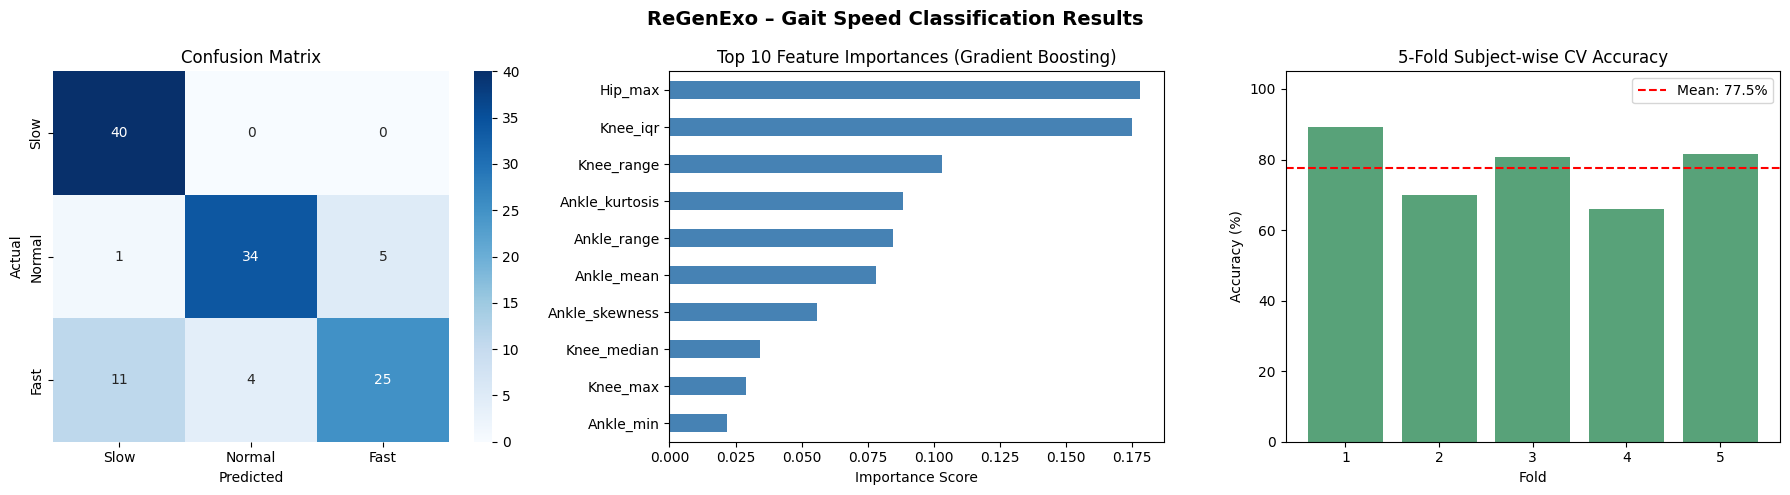

In [19]:
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle('ReGenExo – Gait Speed Classification Results', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes1[0])
axes1[0].set_title('Confusion Matrix')
axes1[0].set_xlabel('Predicted')
axes1[0].set_ylabel('Actual')

if hasattr(final_model, 'feature_importances_'):
    importances = pd.Series(final_model.feature_importances_, index=feature_cols)
    importances.nlargest(10).sort_values().plot(kind='barh', ax=axes1[1], color='steelblue')
    axes1[1].set_title(f'Top 10 Feature Importances ({final_model_name})')
else:
    axes1[1].text(0.5, 0.5, f'{final_model_name} has no\nfeature_importances_',
                   ha='center', va='center', transform=axes1[1].transAxes)
    axes1[1].set_title('Feature Importances (N/A for this model)')
axes1[1].set_xlabel('Importance Score')

axes1[2].bar(range(1, 6), cv_scores * 100, color='seagreen', alpha=0.8)
axes1[2].axhline(cv_scores.mean() * 100, color='red', linestyle='--',
                 label=f'Mean: {cv_scores.mean()*100:.1f}%')
axes1[2].set_title('5-Fold Subject-wise CV Accuracy')
axes1[2].set_xlabel('Fold')
axes1[2].set_ylabel('Accuracy (%)')
axes1[2].set_ylim(0, 105)
axes1[2].legend()

plt.tight_layout()
plt.savefig('regenexo_classification.png', dpi=150, bbox_inches='tight')
plt.show()

8) Plot: Adaptive Torque Output

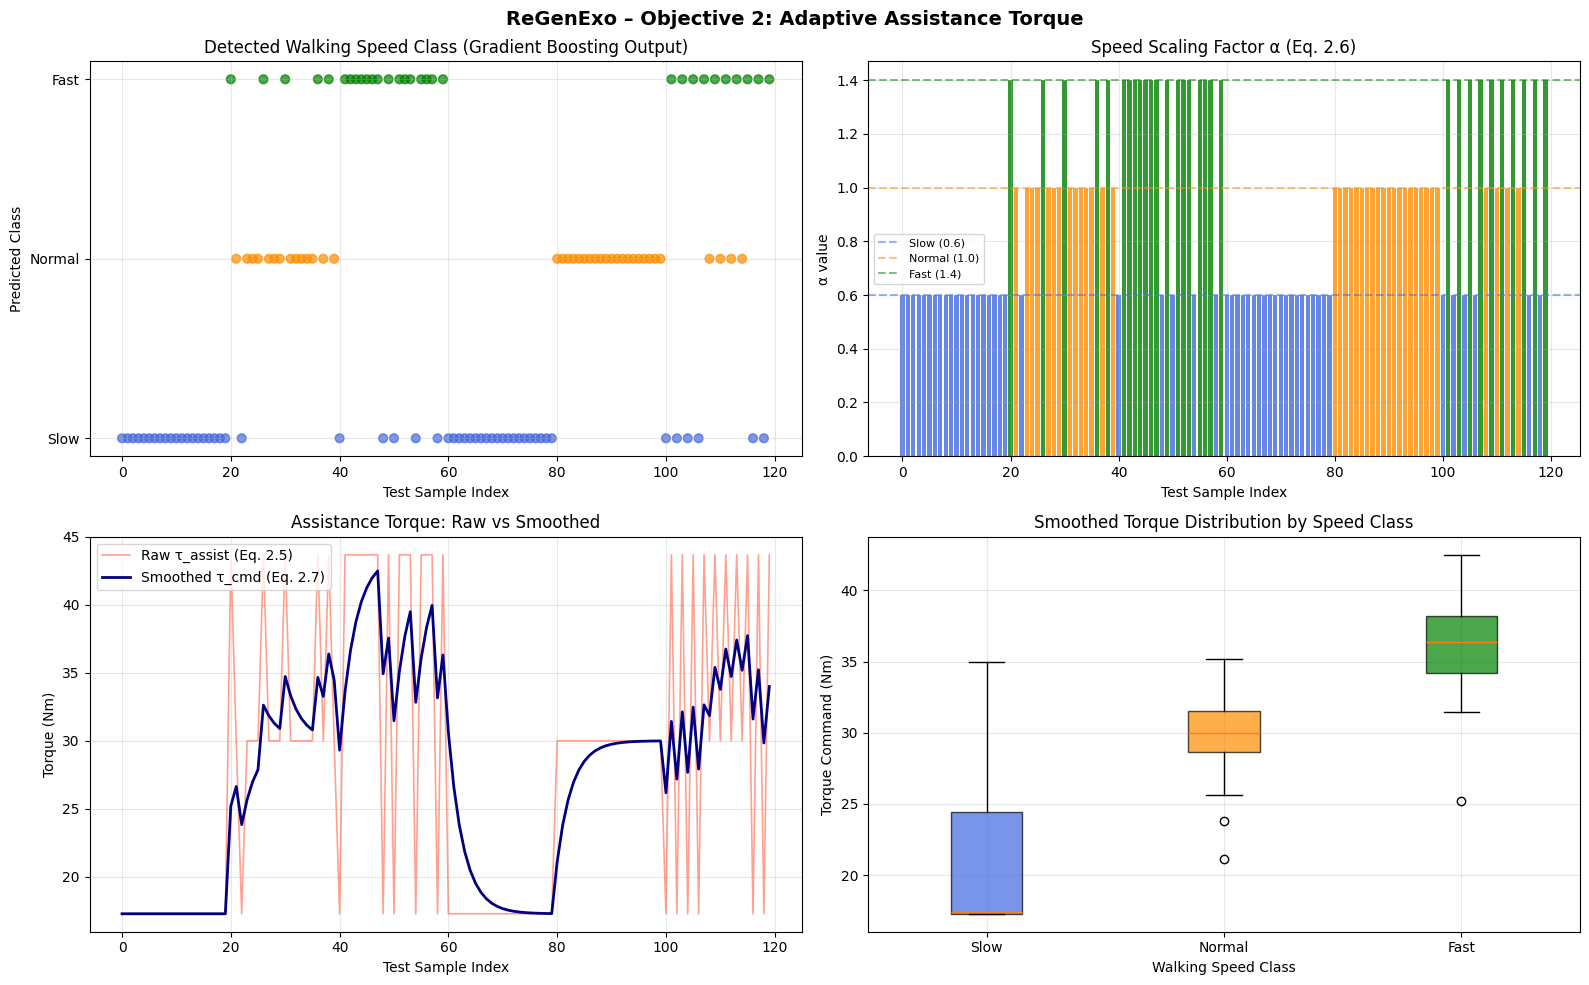

In [20]:
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10))
fig2.suptitle('ReGenExo – Objective 2: Adaptive Assistance Torque', fontsize=14, fontweight='bold')

color_map   = {1: 'royalblue', 2: 'darkorange', 3: 'green'}
colors_pred = [color_map[c] for c in y_pred]

axes2[0, 0].scatter(test_indices, y_pred, c=colors_pred, s=40, alpha=0.7)
axes2[0, 0].set_yticks([1, 2, 3])
axes2[0, 0].set_yticklabels(['Slow', 'Normal', 'Fast'])
axes2[0, 0].set_title(f'Detected Walking Speed Class ({final_model_name} Output)')
axes2[0, 0].set_xlabel('Test Sample Index')
axes2[0, 0].set_ylabel('Predicted Class')
axes2[0, 0].grid(True, alpha=0.3)

alpha_colors = ['royalblue' if a==0.6 else 'darkorange' if a==1.0 else 'green' for a in alpha_vals]
axes2[0, 1].bar(test_indices, alpha_vals, color=alpha_colors, alpha=0.8, width=0.8)
axes2[0, 1].axhline(0.6, color='royalblue',  linestyle='--', alpha=0.5, label='Slow (0.6)')
axes2[0, 1].axhline(1.0, color='darkorange', linestyle='--', alpha=0.5, label='Normal (1.0)')
axes2[0, 1].axhline(1.4, color='green',      linestyle='--', alpha=0.5, label='Fast (1.4)')
axes2[0, 1].set_title('Speed Scaling Factor α (Eq. 2.6)')
axes2[0, 1].set_xlabel('Test Sample Index')
axes2[0, 1].set_ylabel('α value')
axes2[0, 1].legend(fontsize=8)
axes2[0, 1].grid(True, alpha=0.3)

axes2[1, 0].plot(test_indices, tau_assist, color='tomato', alpha=0.6, linewidth=1.2, label='Raw τ_assist (Eq. 2.5)')
axes2[1, 0].plot(test_indices, tau_cmd,    color='navy',   linewidth=2,             label='Smoothed τ_cmd (Eq. 2.7)')
axes2[1, 0].set_title('Assistance Torque: Raw vs Smoothed')
axes2[1, 0].set_xlabel('Test Sample Index')
axes2[1, 0].set_ylabel('Torque (Nm)')
axes2[1, 0].legend()
axes2[1, 0].grid(True, alpha=0.3)

bp = axes2[1, 1].boxplot(
    [torque_by_class['Slow'], torque_by_class['Normal'], torque_by_class['Fast']],
    labels=['Slow', 'Normal', 'Fast'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['royalblue', 'darkorange', 'green']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes2[1, 1].set_title('Smoothed Torque Distribution by Speed Class')
axes2[1, 1].set_xlabel('Walking Speed Class')
axes2[1, 1].set_ylabel('Torque Command (Nm)')
axes2[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regenexo_torque.png', dpi=150, bbox_inches='tight')
plt.show()

9) Plot: Joint Angle Profiles

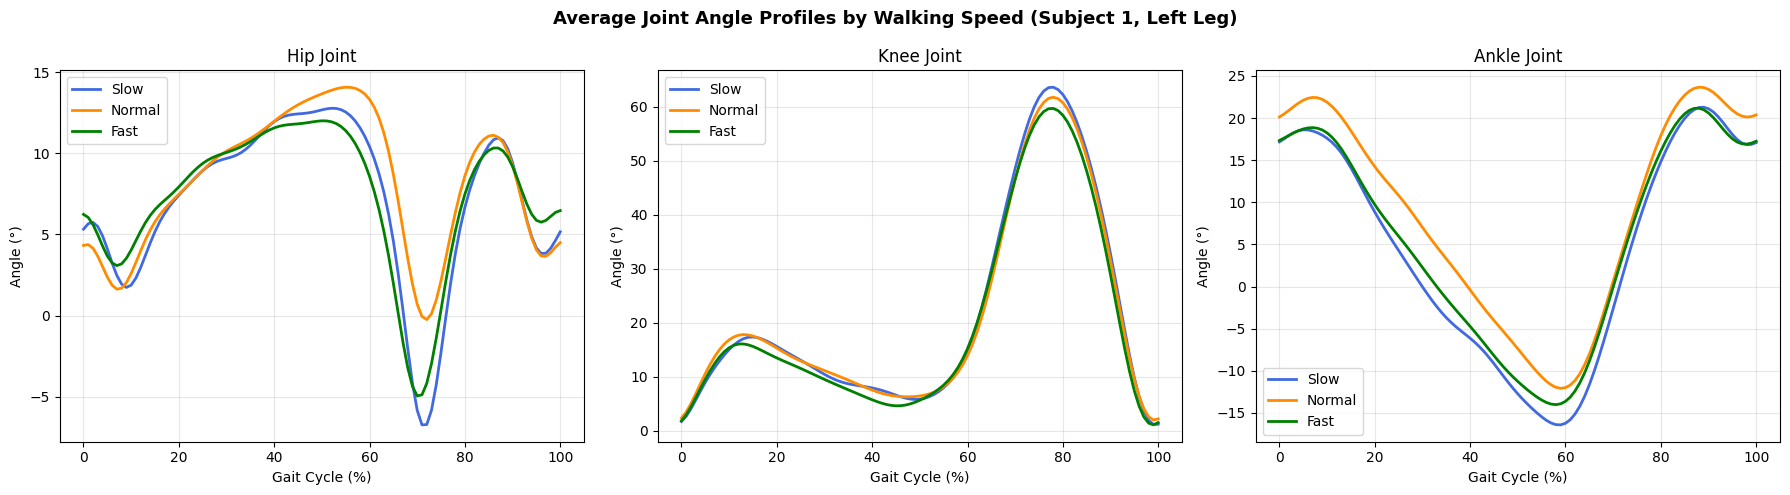

In [21]:
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
fig3.suptitle('Average Joint Angle Profiles by Walking Speed (Subject 1, Left Leg)', fontsize=13, fontweight='bold')

colors_cond = {'Slow': 'royalblue', 'Normal': 'darkorange', 'Fast': 'green'}
sample = df[(df['subject'] == 1) & (df['leg'] == 1)]

for ax, joint in zip(axes3, ['Hip', 'Knee', 'Ankle']):
    for cond_id, cond_label in condition_map.items():
        subset     = sample[(sample['joint_name'] == joint) & (sample['condition'] == cond_id)]
        mean_angle = subset.groupby('time')['angle'].mean()
        ax.plot(mean_angle.index, mean_angle.values,
                label=cond_label, color=colors_cond[cond_label], linewidth=2)
    ax.set_title(f'{joint} Joint')
    ax.set_xlabel('Gait Cycle (%)')
    ax.set_ylabel('Angle (°)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regenexo_joint_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

10) Final Summary

In [22]:
print('=' * 60)
print('  OBJECTIVE 2 — FINAL SUMMARY')
print('=' * 60)
print(f'  {final_model_name} Classifier Accuracy  : {test_acc*100:.1f}%')
print(f'  Subject-wise CV Accuracy : {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%')
print(f'  Torque – Slow  walking  : {torque_by_class["Slow"].mean():.1f} Nm  (α = 0.6)')
print(f'  Torque – Normal walking : {torque_by_class["Normal"].mean():.1f} Nm  (α = 1.0)')
print(f'  Torque – Fast  walking  : {torque_by_class["Fast"].mean():.1f} Nm  (α = 1.4)')
print(f'  Smoothing factor λ      : 0.3')
print()
print('  Equations implemented:')
print(f'  ✅ Eq. 2.2-2.4  {final_model_name} Classification')
print('  ✅ Eq. 2.5      Adaptive Assistance Torque')
print('  ✅ Eq. 2.6      Speed Scaling Factor α')
print('  ✅ Eq. 2.7      Exponential Smoothing Filter')
print()
print('🎉 Objective 2 complete!')

  OBJECTIVE 2 — FINAL SUMMARY
  Gradient Boosting Classifier Accuracy  : 82.5%
  Subject-wise CV Accuracy : 77.5% ± 8.4%
  Torque – Slow  walking  : 21.0 Nm  (α = 0.6)
  Torque – Normal walking : 29.8 Nm  (α = 1.0)
  Torque – Fast  walking  : 36.1 Nm  (α = 1.4)
  Smoothing factor λ      : 0.3

  Equations implemented:
  ✅ Eq. 2.2-2.4  Gradient Boosting Classification
  ✅ Eq. 2.5      Adaptive Assistance Torque
  ✅ Eq. 2.6      Speed Scaling Factor α
  ✅ Eq. 2.7      Exponential Smoothing Filter

🎉 Objective 2 complete!
